In [12]:
#IT/과학 뉴스 45개 엑셀 저장 BeautifulSoup
#🟠 pip install openpyxl 파이썬과 엑셀(.xlsx) 파일을 연결하는
import requests
import pandas as pd
from bs4 import BeautifulSoup

# 1. 뉴스 데이터 가져오기 (네이버 검색 결과 기준) User-Agent는 사람이라고 속이는 신분증
url = 'https://news.naver.com/main/main.naver?mode=LSD&mid=shm&sid1=105'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36'}

# 1-2. url로 가서 데이터 가져와 response 변수로 대입
response = requests.get(url, headers=headers) # headers의 신분증 (로봇 아니라고)
soup = BeautifulSoup(response.text, 'html.parser')
titles = soup.select('.sa_text_strong') # 🟠🔴 찾으신 클래스 이름으로 확인! sa_text_title

# 2. 리스트에 제목들을 담기 
news_titles = [] # 1️⃣빈 주머니 준비. 변수에 차곡차곡 저장됨
for title in titles: # "내용물(titles)에서 하나씩(title) 꺼내와!" 끝에 콜론:
    news_titles.append(title.text)
    #clean_title = title.text.strip() # 🍋2️⃣앞뒤 지저분한 제거 -아래2줄(원할 시)
    #news_titles.append(clean_title)

# 3. 🟠3️⃣ 핵심: 리스트를 Pandas의 데이터프레임(df_news) 변수로 저장 ★
# df_news변수 저장: 단순한 글자 뭉치를 **'구조화된 표'**로 바꾸는 순간
df_news = pd.DataFrame(news_titles, columns=['IT/과학 분야 뉴스'])

# 4. 결과 확인 및 엑셀 저장 -45개
print("--- 데이터프레임 생성 완료 ---")
# print(df_news.head()) # 상위 5개 미리보기
df_news.head() #4️⃣
# 5. 엑셀 파일로 내보내기5️⃣ (확인 후 닫기 - 열어보고 있으면 오류🍋)
# df_news.to_excel('news_results.xlsx', index=False)
# print("--- news_results.xlsx 파일 저장 완료! ---") #\n줄바꿈

--- 데이터프레임 생성 완료 ---


,IT/과학 분야 뉴스
0,"라온시큐어, AI 사업체제 전환에 공채 모집 열기…2600여명 몰려 경쟁률 130대..."
1,스탠퍼드 “미중 AI격차 사라져”…한국은 ‘주목할 AI’ 세계 3위
2,"우주청, 미국·UAE 등과 연쇄 회동…우주동맹 확대"
3,"삼성SDS, KKR 1.2조 투자 유치…AI·M&A 가속화"
4,"""AI 스마트 콘택트렌즈 끼고 눈짓만으로 로봇 조종"""


In [13]:
# 엑셀 파일 읽기 p247 (파일명 오타 유의)
loaded_df = pd.read_excel('news_results.xlsx')
print("👌👌엑셀 불러오기 성공!")

# 확장자 종류 .csv .json .txt
# pd.read_csv pd.read_json pd.read_txt

👌👌엑셀 불러오기 성공!


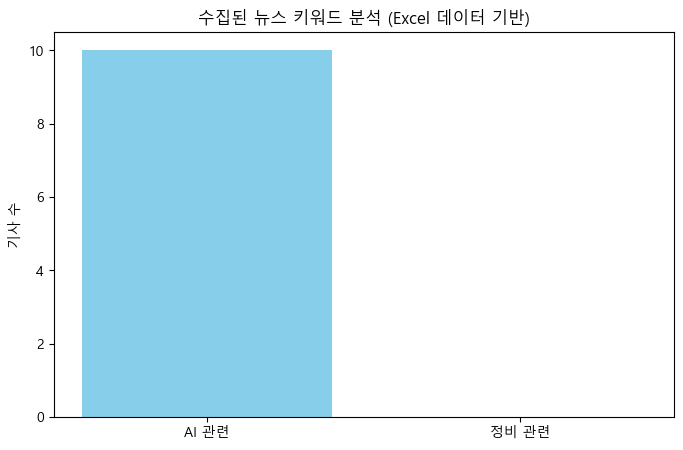

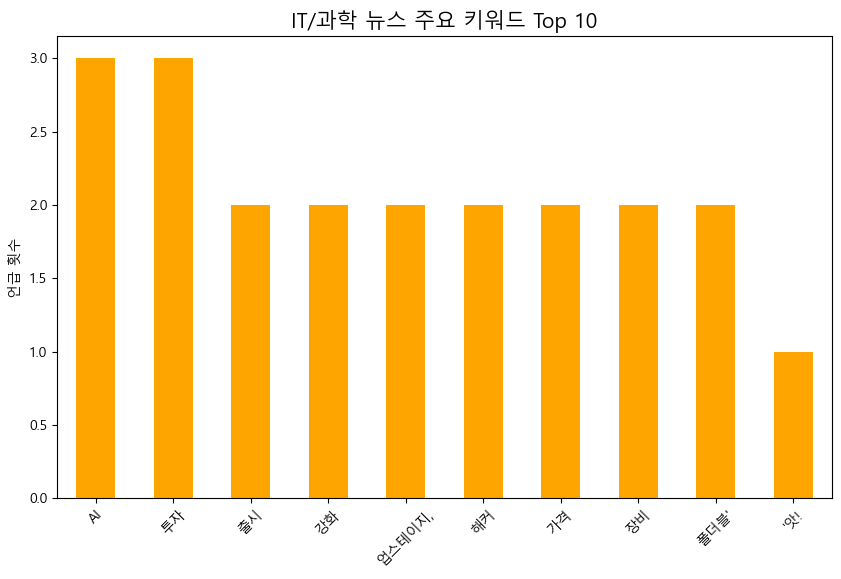

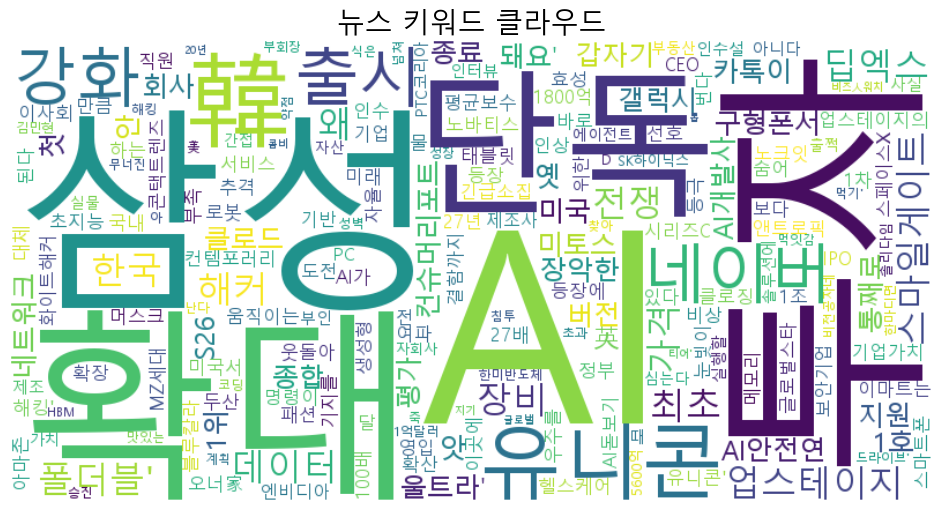

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 한글 설정 (생략 가능)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1️⃣🟢불러온 데이터 엑셀(loaded_df)에서 개수 세기 'AI'나 '교육' 대신 다른 단어 넣어보기
ai_count = loaded_df['IT/과학 분야 뉴스'].str.contains('AI').sum()
python_count = loaded_df['IT/과학 분야 뉴스'].str.contains('정비').sum()

# 1️⃣🟢그래프 그리기 - 🟢오늘은 1번만 2~3은 3일째날
plt.figure(figsize=(8, 5)) # 그래프 크기 설정
plt.bar(['AI 관련', '정비 관련'], [ai_count, python_count], color=['skyblue', 'green'])
plt.title('수집된 뉴스 키워드 분석 (Excel 데이터 기반)')
plt.ylabel('기사 수')
plt.show()

# 2️⃣1. 모든 뉴스 제목을 하나의 긴 문장으로 합치기
all_titles = " ".join(loaded_df['IT/과학 분야 뉴스'].astype(str))
# 2. 단어 단위로 쪼개기 (공백 기준)
words = all_titles.split()
# 3. 단어별 개수 세기 (Pandas Series 활용)
word_counts = pd.Series(words).value_counts()
# 4. 너무 짧은 단어(1글자)나 의미 없는 단어 제외 (전처리 실습)
# 예: '의', '가', '이' 등 제외
word_counts = word_counts[word_counts.index.str.len() > 1]
# 5. 상위 10개만 뽑기
top10 = word_counts.head(10)
# 6. 막대그래프 그리기
plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color='orange') #또는 top10.plot.bar() #df.plot.bar() p403
plt.title('IT/과학 뉴스 주요 키워드 Top 10', fontsize=15)
plt.ylabel('언급 횟수')
plt.xticks(rotation=45)
plt.show()

# 3️⃣2. 워드클라우드 생성
wc = WordCloud(
    font_path='malgun',
    background_color='white',
    width=800,
    height=400
).generate(all_titles) # 위에서 합친 문장 사용

# 3. 화면에 표시
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off') # 테두리 숫자 끄기
plt.title('뉴스 키워드 클라우드', fontsize=20)
plt.show()

엑셀 오류시 설치!
pip install openpyxl